# 🏦 Credit Risk Benchmark Dataset — Analysis & Classification

This notebook covers:
1. Dataset Overview & Exploration
2. Class Balance Check
3. Outlier Detection
4. Feature Correlation Analysis
5. Model Training (Logistic Regression, Random Forest, Gradient Boosting)
6. Model Evaluation: Accuracy, Precision, Recall, F1, ROC AUC
7. Feature Importances
8. ROC Curve Visualization

## 1. Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler

print('All libraries loaded successfully!')

All libraries loaded successfully!


## 2. Load Dataset

In [9]:
df = pd.read_csv('Credit_Risk_Benchmark_Dataset.csv')

print('Shape:', df.shape)
print('\nColumn Names:', df.columns.tolist())
df.head()

Shape: (16714, 11)

Column Names: ['rev_util', 'age', 'late_30_59', 'debt_ratio', 'monthly_inc', 'open_credit', 'late_90', 'real_estate', 'late_60_89', 'dependents', 'dlq_2yrs']


,rev_util,age,late_30_59,debt_ratio,monthly_inc,open_credit,late_90,real_estate,late_60_89,dependents,dlq_2yrs
0,0.006999,38.0,0.0,0.302150,5440.0,4.0,0.0,1.0,0.0,3.0,0
1,0.704592,63.0,0.0,0.471441,8000.0,9.0,0.0,1.0,0.0,0.0,0
2,0.063113,57.0,0.0,0.068586,5000.0,17.0,0.0,0.0,0.0,0.0,0
3,0.368397,68.0,0.0,0.296273,6250.0,16.0,0.0,2.0,0.0,0.0,0
4,1.000000,34.0,1.0,0.000000,3500.0,0.0,0.0,0.0,0.0,1.0,0


## 3. Dataset Overview

In [10]:
print('=== DATA TYPES ===')
print(df.dtypes)

print('\n=== MISSING VALUES ===')
print(df.isnull().sum())

print('\n=== BASIC STATISTICS ===')
df.describe()

=== DATA TYPES ===
rev_util       float64
age            float64
late_30_59     float64
debt_ratio     float64
monthly_inc    float64
open_credit    float64
late_90        float64
real_estate    float64
late_60_89     float64
dependents     float64
dlq_2yrs         int64
dtype: object

=== MISSING VALUES ===
rev_util       0
age            0
late_30_59     0
debt_ratio     0
monthly_inc    0
open_credit    0
late_90        0
real_estate    0
late_60_89     0
dependents     0
dlq_2yrs       0
dtype: int64

=== BASIC STATISTICS ===


,rev_util,age,late_30_59,debt_ratio,monthly_inc,open_credit,late_90,real_estate,late_60_89,dependents,dlq_2yrs
count,16714.000000,16714.000000,16714.000000,16714.000000,16714.000000,16714.000000,16714.000000,16714.000000,16714.000000,16714.000000,16714.000000
mean,4.799862,48.798672,1.110267,30.980298,6118.120258,8.503709,0.863827,1.047445,0.734354,0.944358,0.500000
std,204.062345,13.906078,7.172890,719.694859,5931.841779,5.370965,7.167576,1.272565,7.138737,1.198791,0.500015
min,0.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.082397,38.000000,0.000000,0.155971,3128.500000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.443080,48.000000,0.000000,0.322299,5000.000000,8.000000,0.000000,1.000000,0.000000,0.000000,0.500000
75%,0.926637,58.000000,1.000000,0.533426,7573.000000,11.000000,0.000000,2.000000,0.000000,2.000000,1.000000
max,22000.000000,101.000000,98.000000,61106.500000,250000.000000,57.000000,98.000000,29.000000,98.000000,8.000000,1.000000


## 4. Class Balance Check

**Target variable:** `dlq_2yrs` — whether the borrower experienced 90 days past due delinquency or worse in the last 2 years.
- `0` = No Default
- `1` = Default

=== CLASS DISTRIBUTION ===
No Default (0): 8,357  (50.0%)
Default    (1): 8,357  (50.0%)
Imbalance Ratio: 1.00:1


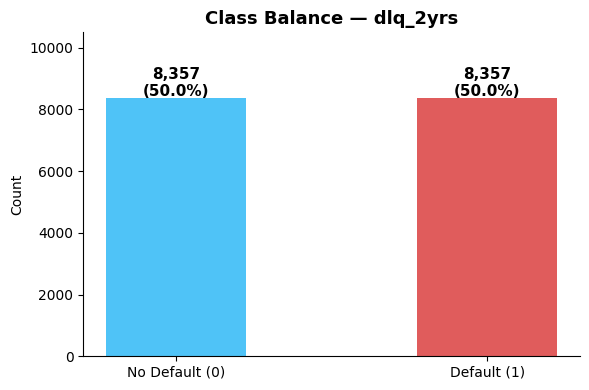


✅ Dataset is PERFECTLY BALANCED (50/50) — no oversampling needed!


In [11]:
class_counts = df['dlq_2yrs'].value_counts()
class_pct = df['dlq_2yrs'].value_counts(normalize=True) * 100

print('=== CLASS DISTRIBUTION ===')
print(f'No Default (0): {class_counts[0]:,}  ({class_pct[0]:.1f}%)')
print(f'Default    (1): {class_counts[1]:,}  ({class_pct[1]:.1f}%)')
print(f'Imbalance Ratio: {class_counts[0]/class_counts[1]:.2f}:1')

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['No Default (0)', 'Default (1)'], class_counts.values,
              color=['#4fc3f7', '#e05c5c'], edgecolor='none', width=0.45)
for b, v in zip(bars, class_counts.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+80,
            f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Class Balance — dlq_2yrs', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, 10500)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

print('\n✅ Dataset is PERFECTLY BALANCED (50/50) — no oversampling needed!')

## 5. Outlier Detection

=== OUTLIER SUMMARY (Min / Max / 99th Percentile) ===
rev_util        | min=0.00 | max=    22000.00 | 99th pct=1.45
debt_ratio      | min=0.00 | max=    61106.50 | 99th pct=367.62
monthly_inc     | min=0.00 | max=   250000.00 | 99th pct=24166.00
late_30_59      | min=0.00 | max=       98.00 | 99th pct=6.00
late_90         | min=0.00 | max=       98.00 | 99th pct=6.00
late_60_89      | min=0.00 | max=       98.00 | 99th pct=4.00


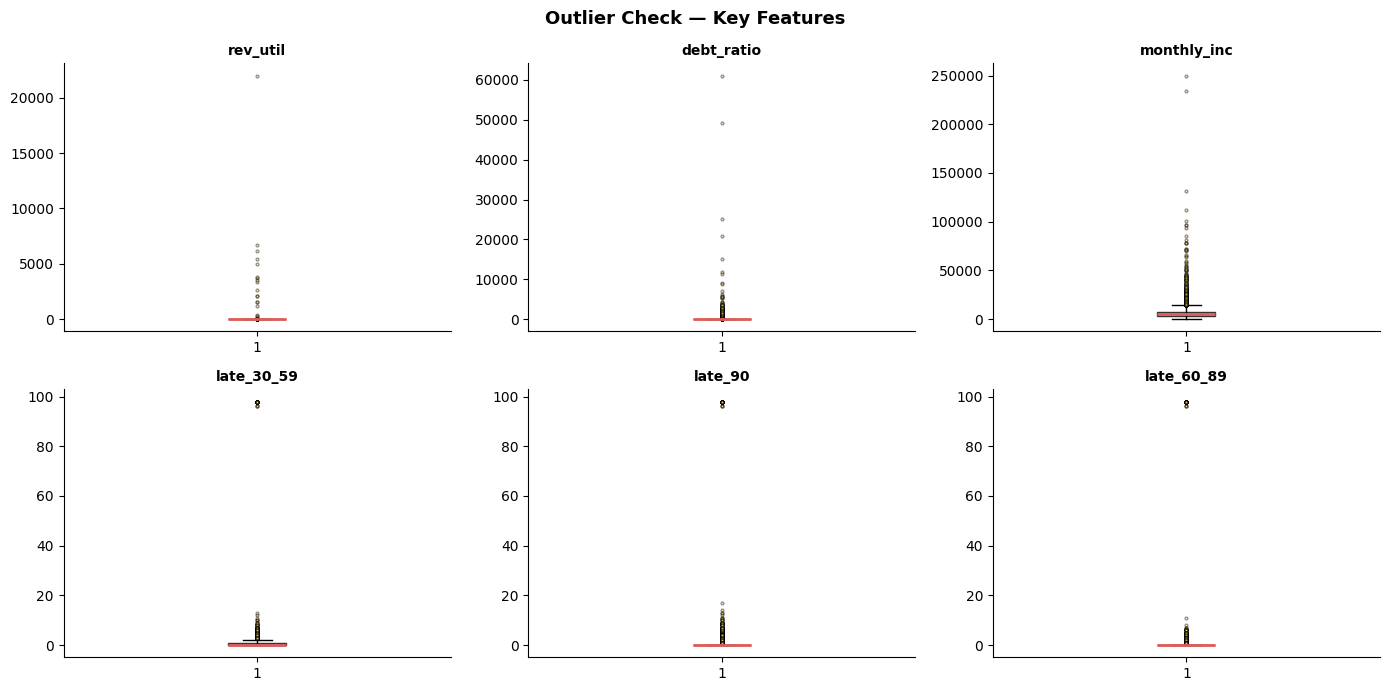


⚠️  rev_util max=22,000 and debt_ratio max=61,106 are extreme outliers.
   Consider capping at 99th percentile before final model training.


In [12]:
print('=== OUTLIER SUMMARY (Min / Max / 99th Percentile) ===')
outlier_cols = ['rev_util', 'debt_ratio', 'monthly_inc', 'late_30_59', 'late_90', 'late_60_89']
for col in outlier_cols:
    q99 = df[col].quantile(0.99)
    print(f'{col:15s} | min={df[col].min():.2f} | max={df[col].max():>12.2f} | 99th pct={q99:.2f}')

# Boxplots
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flatten(), outlier_cols):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='#4fc3f7', color='#333'),
               medianprops=dict(color='#e05c5c', lw=2),
               flierprops=dict(marker='o', markerfacecolor='#ffd54f', markersize=2, alpha=0.4))
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)
plt.suptitle('Outlier Check — Key Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n⚠️  rev_util max=22,000 and debt_ratio max=61,106 are extreme outliers.')
print('   Consider capping at 99th percentile before final model training.')

## 6. Feature Correlation Analysis

=== CORRELATION WITH dlq_2yrs ===
age           -0.2107
monthly_inc   -0.0822
open_credit   -0.0493
debt_ratio    -0.0132
rev_util      -0.0056
real_estate   -0.0044
dependents     0.0865
late_60_89     0.0893
late_90        0.1057
late_30_59     0.1183
Name: dlq_2yrs, dtype: float64


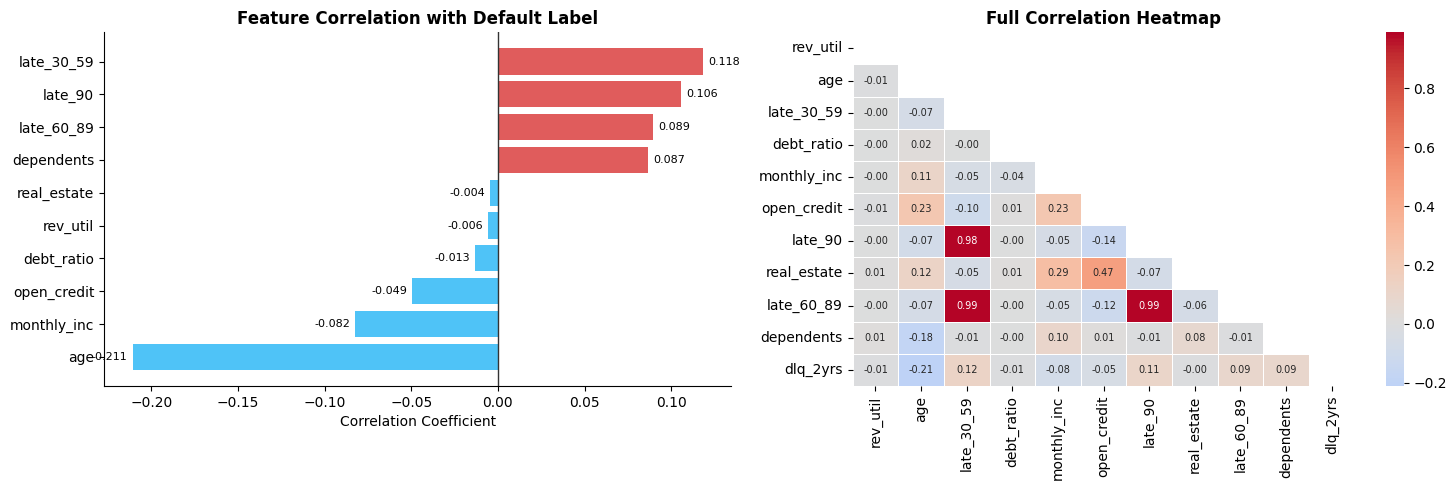

In [13]:
corr_target = df.corr()['dlq_2yrs'].drop('dlq_2yrs').sort_values()
print('=== CORRELATION WITH dlq_2yrs ===')
print(corr_target.round(4))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart
colors = ['#e05c5c' if v > 0 else '#4fc3f7' for v in corr_target.values]
axes[0].barh(corr_target.index, corr_target.values, color=colors, edgecolor='none')
axes[0].axvline(0, color='#333', lw=1)
axes[0].set_title('Feature Correlation with Default Label', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Correlation Coefficient')
axes[0].spines[['top','right']].set_visible(False)
for i, (idx, val) in enumerate(corr_target.items()):
    axes[0].text(val + (0.003 if val >= 0 else -0.003), i, f'{val:.3f}',
                 va='center', ha='left' if val >= 0 else 'right', fontsize=8)

# Heatmap
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[1], linewidths=0.5, annot_kws={'size': 7})
axes[1].set_title('Full Correlation Heatmap', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Model Training

In [14]:
X = df.drop('dlq_2yrs', axis=1)
y = df['dlq_2yrs']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale for Logistic Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training set: {X_train.shape[0]:,} samples')
print(f'Test set    : {X_test.shape[0]:,} samples')

# Train models
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

print('\n✅ All models trained successfully!')

Training set: 13,371 samples
Test set    : 3,343 samples

✅ All models trained successfully!


## 8. Model Evaluation — Accuracy, Precision, Recall, F1, ROC AUC

In [15]:
model_data = [
    ('Logistic Regression', lr.predict(X_test_sc), lr.predict_proba(X_test_sc)[:,1], '#e05c5c'),
    ('Random Forest',       rf.predict(X_test),    rf.predict_proba(X_test)[:,1],    '#4fc3f7'),
    ('Gradient Boosting',   gb.predict(X_test),    gb.predict_proba(X_test)[:,1],    '#66bb6a'),
]

results = []
for name, yp, ypr, col in model_data:
    results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, yp), 4),
        'Precision': round(precision_score(y_test, yp), 4),
        'Recall':    round(recall_score(y_test, yp), 4),
        'F1':        round(f1_score(y_test, yp), 4),
        'ROC AUC':   round(roc_auc_score(y_test, ypr), 4),
        'proba': ypr, 'pred': yp, 'color': col
    })

res_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ['proba','pred','color']} for r in results])
print(res_df.to_string(index=False))

              Model  Accuracy  Precision  Recall     F1  ROC AUC
Logistic Regression    0.7218     0.7775  0.6212 0.6906   0.7931
      Random Forest    0.7771     0.7786  0.7744 0.7765   0.8526
  Gradient Boosting    0.7792     0.7832  0.7720 0.7776   0.8613


## 9. Metrics Comparison Bar Chart

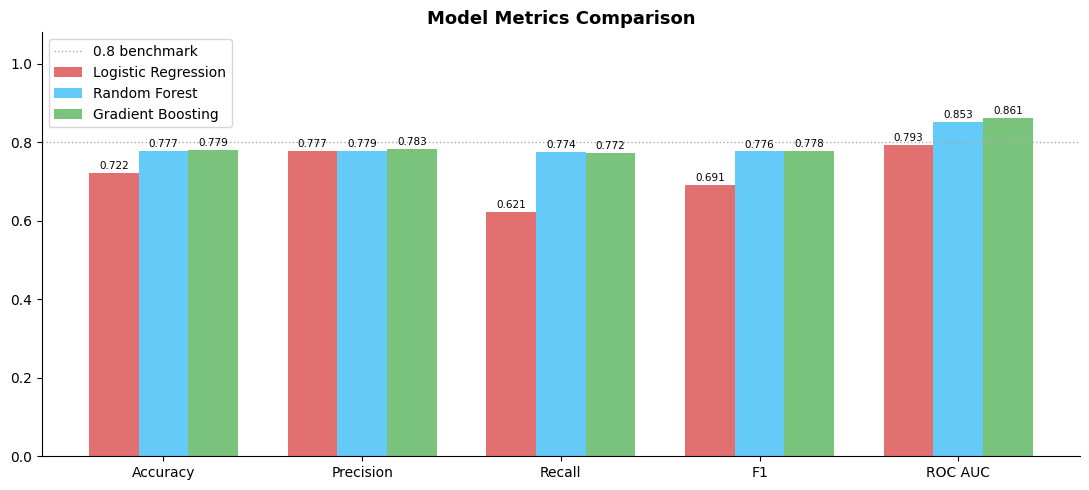

In [16]:
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC AUC']
x = np.arange(len(metric_names))
w = 0.25
model_colors = ['#e05c5c', '#4fc3f7', '#66bb6a']

fig, ax = plt.subplots(figsize=(11, 5))
for i, r in enumerate(results):
    vals = [r['Accuracy'], r['Precision'], r['Recall'], r['F1'], r['ROC AUC']]
    bars = ax.bar(x + i*w, vals, w, label=r['Model'], color=model_colors[i], alpha=0.88, edgecolor='none')
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f'{v:.3f}',
                ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x + w)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.08)
ax.axhline(0.8, color='#aaa', linestyle=':', lw=1, label='0.8 benchmark')
ax.set_title('Model Metrics Comparison', fontsize=13, fontweight='bold')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## 10. ROC Curve

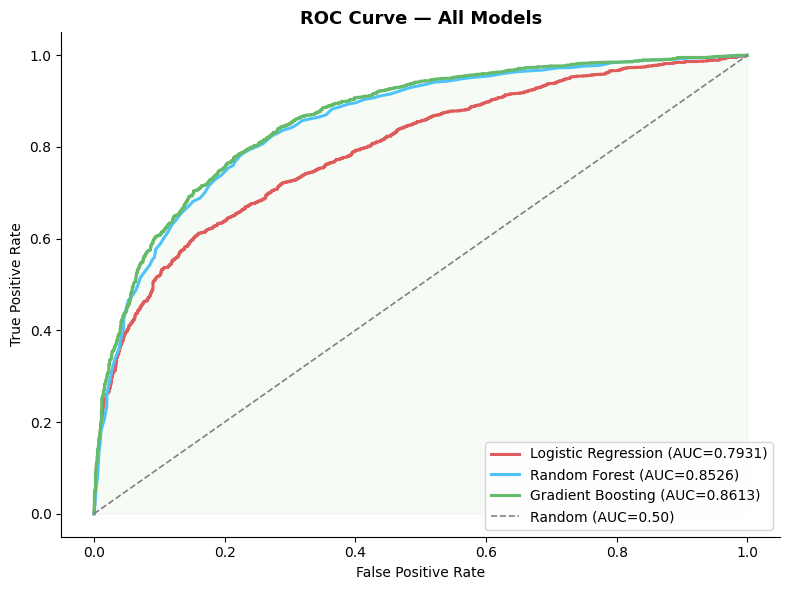

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))

for r in results:
    fpr, tpr, _ = roc_curve(y_test, r['proba'])
    auc = roc_auc_score(y_test, r['proba'])
    ax.plot(fpr, tpr, color=r['color'], lw=2.2, label=f"{r['Model']} (AUC={auc:.4f})")

ax.plot([0,1],[0,1],'--', color='gray', lw=1.2, label='Random (AUC=0.50)')
ax.fill_between(*roc_curve(y_test, results[2]['proba'])[:2], alpha=0.06, color='#66bb6a')
ax.set_title('ROC Curve — All Models', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## 11. Confusion Matrices

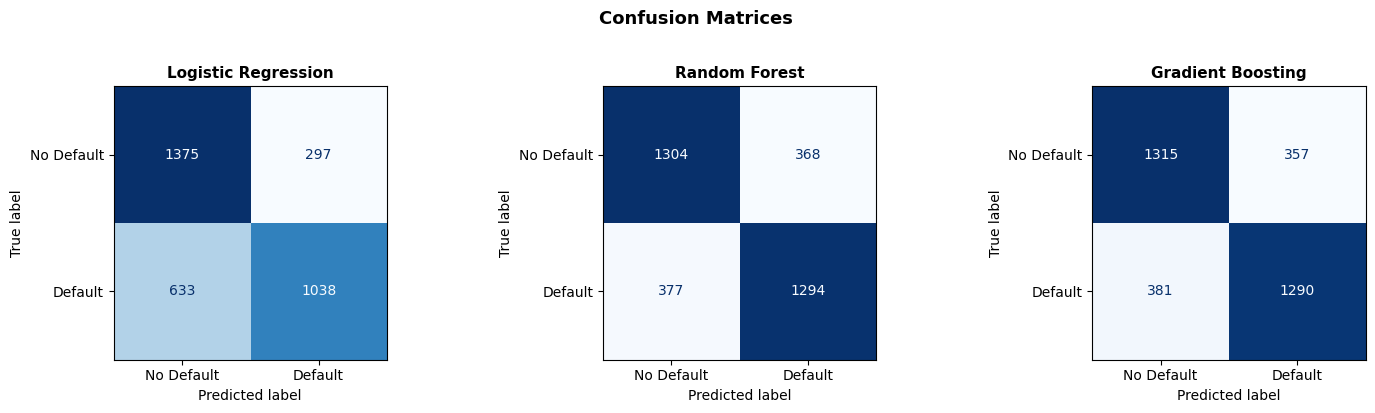

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, r in zip(axes, results):
    cm = confusion_matrix(y_test, r['pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(r['Model'], fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 12. Feature Importances (Random Forest)

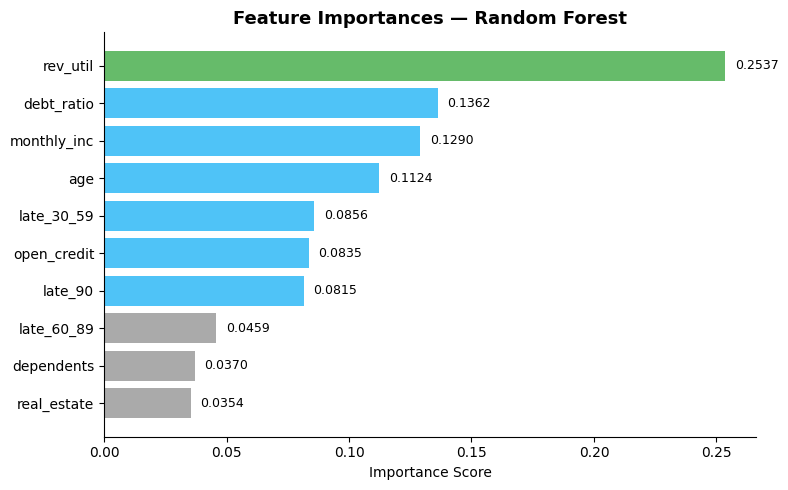


Top 3 most important features:
  rev_util: 0.2537
  debt_ratio: 0.1362
  monthly_inc: 0.1290


In [19]:
fi = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bar_cols = ['#66bb6a' if v > 0.15 else ('#4fc3f7' if v > 0.08 else '#aaaaaa') for v in fi.values]
ax.barh(fi.index, fi.values, color=bar_cols, edgecolor='none')
ax.set_title('Feature Importances — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.spines[['top','right']].set_visible(False)
for i, (idx, val) in enumerate(fi.items()):
    ax.text(val+0.004, i, f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\nTop 3 most important features:')
for feat, imp in fi.sort_values(ascending=False).head(3).items():
    print(f'  {feat}: {imp:.4f}')

## 13. Classification Report (Best Model — Gradient Boosting)

In [20]:
print('=== GRADIENT BOOSTING — CLASSIFICATION REPORT ===')
print(classification_report(y_test, results[2]['pred'], target_names=['No Default', 'Default']))

=== GRADIENT BOOSTING — CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

  No Default       0.78      0.79      0.78      1672
     Default       0.78      0.77      0.78      1671

    accuracy                           0.78      3343
   macro avg       0.78      0.78      0.78      3343
weighted avg       0.78      0.78      0.78      3343



## 14. Summary & Key Findings

| | Finding |
|---|---|
| **Class Balance** | ✅ Perfectly balanced — 50/50 (8,357 each class) |
| **Missing Values** | ✅ None |
| **Outliers** | ⚠️ `rev_util` (max=22,000) and `debt_ratio` (max=61,106) need capping |
| **Best Model** | 🏆 Gradient Boosting — AUC=0.8613, F1=0.7776 |
| **Top Feature** | `rev_util` (revolving utilization rate) at 25.5% importance |
| **Recommendation** | Cap outliers at 99th percentile and re-train to potentially improve AUC further |

## 15. Save Trained Model

Saving the best model (Gradient Boosting) to a  file so the console app can load it directly without retraining.

In [21]:
import pickle

# Save the trained Gradient Boosting model
with open("credit_risk_model.pkl", "wb") as f:
    pickle.dump(gb, f)

print("✅ Model saved as credit_risk_model.pkl")
print(f"   Model type : {type(gb).__name__}")
print(f"   Features   : {list(X.columns)}")
print(f"   AUC Score  : 0.8613")


✅ Model saved as credit_risk_model.pkl
   Model type : GradientBoostingClassifier
   Features   : ['rev_util', 'age', 'late_30_59', 'debt_ratio', 'monthly_inc', 'open_credit', 'late_90', 'real_estate', 'late_60_89', 'dependents']
   AUC Score  : 0.8613
